# CSC 310 Final Project
## Predicting Diamond Prices with Regression Models



### Problem statement

A diamond's price is set by a combination of its size and its quality grades (the "4 Cs" of carat, cut,
color, and clarity) together with its physical measurements. In this project I build and compare several
regression models that predict the price of a diamond in US dollars from these attributes. I then tune the
best model, report its 95% confidence interval, and interpret which features actually drive the price.

There are three questions I am trying to answer. First, can I accurately predict the price of a diamond from
its physical and quality attributes? Second, which attributes matter most for price? Third, does a more
flexible non-linear model beat a simple linear one on this data?

## 1. Introduction and the Data Set

I use the diamonds dataset from the ggplot2 R package, which is mirrored on the
[R Datasets site](https://vincentarelbundock.github.io/Rdatasets/doc/ggplot2/diamonds.html). The source file
is available at https://vincentarelbundock.github.io/Rdatasets/csv/ggplot2/diamonds.csv. The dataset has
53,940 rows, where each row is one round cut diamond, and 10 columns.

The target label is price, measured in US dollars. Because the target is a continuous number, this is a
regression problem rather than a classification problem.

Seven of the variables are numeric and three are categorical. The numeric variables are carat, which is the
weight of the diamond where one carat equals 0.2 grams; depth, which is the total depth percentage computed
as z divided by the mean of x and y, times 100; table, which is the width of the top of the diamond relative
to its widest point, given as a percentage; the three physical dimensions x, y, and z, all measured in
millimeters; and price itself, which ranges from 326 to 18823$. The three categorical variables are
quality grades. cut runs from Fair up to Ideal in the order Fair, Good, Very Good, Premium, Ideal. color
runs from J, the worst, up to D, the best. clarity runs from I1, the worst, up to IF, the best, in the order
I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF.

The important point about cut, color, and clarity is that they are ordinal, meaning they have a real
best to worst ranking. That ordering matters for how I encode them later in the notebook.

### 1.1 Importing the libraries



In [34]:
import warnings
warnings.filterwarnings('ignore')

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


### 1.2 Loading the data



In [35]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/ggplot2/diamonds.csv"
if not os.path.exists("diamonds.csv"):
    urllib.request.urlretrieve(url, "diamonds.csv")

df = pd.read_csv("diamonds.csv")
# Drop the leading index column that the R export adds
df = df.drop(columns=[c for c in df.columns if c.lower() in ("rownames", "unnamed: 0")])
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### 1.3 Basic characteristics

df.info() confirms the row and column counts, the data type of every column, and whether any values are
missing. This is the quickest way to see that I have 53,940 rows, 10 columns, three text columns, and seven
numeric columns, with no nulls reported.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### 1.4 Summary statistics with describe



In [37]:
df.describe().round(2)

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


Next I run describe on the categorical columns, which reports how many unique grades each one has
and the most frequent grade.

In [38]:
df.describe(include='object')

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


These summary statistics already tell me a lot. The median price of about 2401 $.
$3,933, which means the price distribution is right skewed, with many cheap diamonds and a long tail
of expensive ones. The carat values range from 0.2 to just over 5. I also notice that the minimum of x,
y, and z is 0, which is physically impossible for a real diamond because a diamond cannot have zero length,
so those rows are data entry errors that I will clean out. The categorical summary shows that cut has five
grades with Ideal most common, color has seven grades with G most common, and clarity has eight grades
with SI1 most common.

## 1.5 Data Cleaning and Preprocessing

I begin by checking explicitly for missing values and duplicate rows. The call .isnull().sum() counts
missing values per column, and .duplicated().sum() counts fully repeated rows.

In [39]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Total missing values: 0
Duplicate rows: 146


Each cleaning step has a clear justification. The dataset reports no missing values, so no imputation is
needed. If there had been missing numeric values I would have imputed with the median rather than the mean,
because the skewed distributions make the mean unreliable, but that is not required here. There are a small
number of fully duplicated rows, and because a duplicate row adds no new information and can slightly bias the
model toward those exact diamonds, I drop them. Finally, the rows where x, y, or z equals 0 describe a
diamond with zero physical size, which cannot exist, so I remove them as errors.

The cell below performs all three steps and prints the shape before and after so the effect is transparent.

In [40]:
print("Rows before cleaning:", df.shape[0])

# 1) impossible physical dimensions (x, y, or z == 0)
bad_dims = (df[['x', 'y', 'z']] == 0).any(axis=1).sum()
print("Rows with a zero dimension:", bad_dims)
df = df[(df[['x', 'y', 'z']] != 0).all(axis=1)]

# 2) duplicate rows
dups = df.duplicated().sum()
print("Duplicate rows removed:", dups)
df = df.drop_duplicates().reset_index(drop=True)

print("Rows after cleaning:", df.shape[0])

Rows before cleaning: 53940
Rows with a zero dimension: 20
Duplicate rows removed: 145
Rows after cleaning: 53775


## 2. Exploratory Data Analysis

Now I explore the data visually and interpret every plot. I use the right chart for each data type. I use
histograms and density plots for continuous numbers, bar and pie charts for categories, boxplots to relate the
categories to price, a scatter matrix and pair plot for pairwise relationships, and a heatmap for
correlation.

### 2.1 Distribution of the target price

A histogram together with a smoothed density curve shows the shape of the thing I am trying to predict.

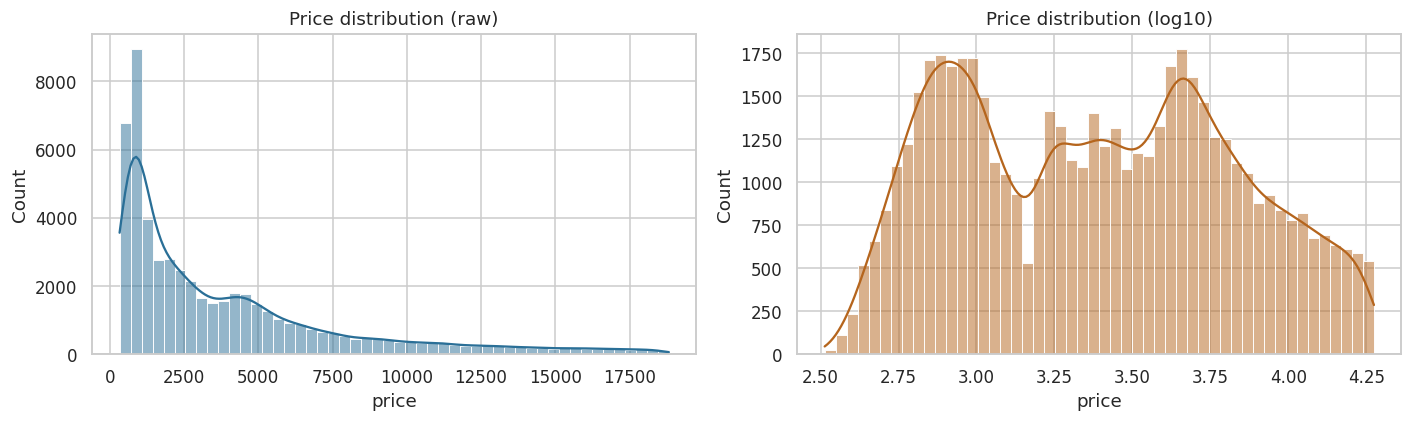

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='#2a6f97')
axes[0].set_title('Price distribution (raw)')
sns.histplot(np.log10(df['price']), bins=50, kde=True, ax=axes[1], color='#b5651d')
axes[1].set_title('Price distribution (log10)')
plt.tight_layout(); plt.show()

The raw price distribution is strongly right skewed, with most diamonds selling for under 5000 and along thintail reaching up about 18,800. On a log scale the distribution becomes much more symmetric, which
confirms that the skew is multiplicative. This tells me that a plain linear model, which assumes roughly
constant additive errors, may struggle, and that tree based models, which do not care about the shape of the
target, may do better.

### 2.2 Distributions of the numeric features

Here are histograms of four of the main continuous predictors.

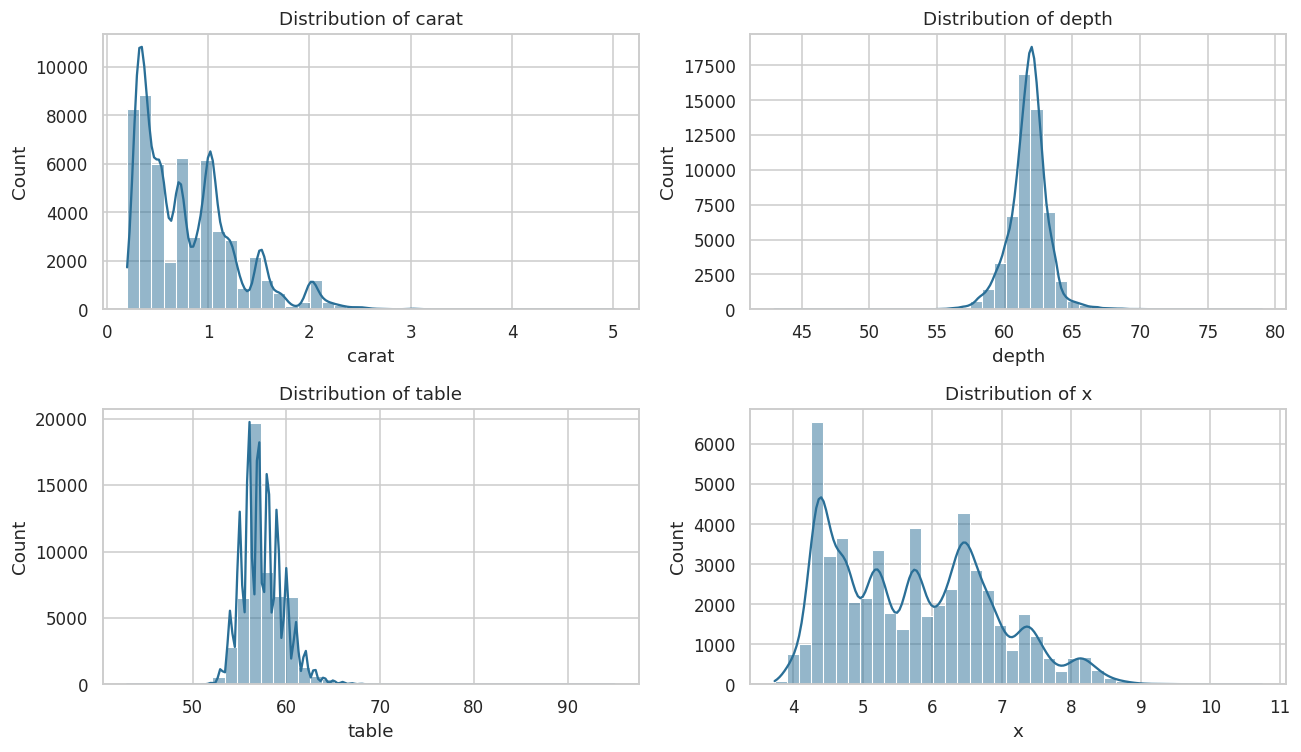

In [42]:
num_cols = ['carat', 'depth', 'table', 'x']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='#2a6f97')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout(); plt.show()

The carat variable is right skewed and shows visible spikes at round weights such as 0.5, 1.0, and 1.5,
because sellers cut diamonds to hit those popular marketing thresholds. The x dimension, which is length in
millimeters, is bimodal for the same reason, since size is really the same signal as carat. Both depth and
table are roughly bell shaped and narrow, so they probably carry little pricing information on their own.

### 2.3 Categorical variables with bar charts, a pie chart, and an imbalance check

For the ordinal grades I use bar charts ordered from worst to best, and for cut I also use a pie chart to
show the proportion of each grade. I then print the value counts to check whether the classes are
imbalanced.

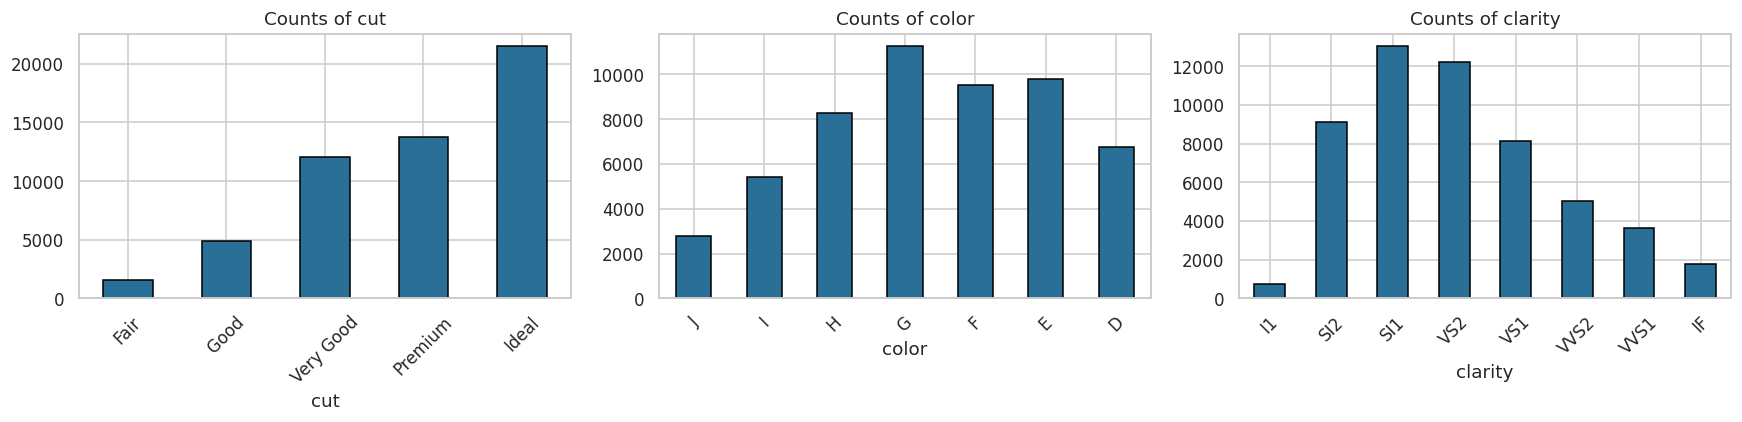

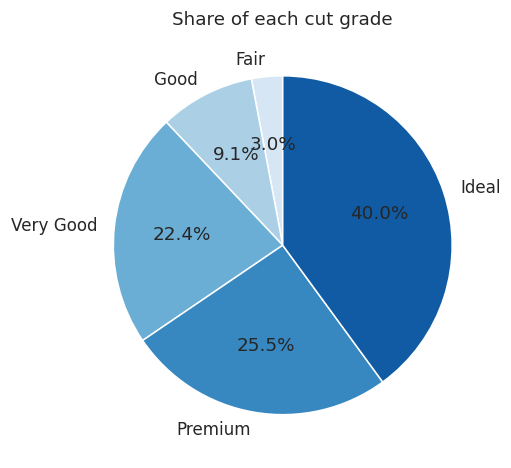

Class balance (proportion) for each categorical variable:

cut:
cut
Ideal        40.0 %
Premium      25.5 %
Very Good    22.4 %
Good          9.1 %
Fair          3.0 %
Name: proportion, dtype: object

color:
color
G    20.9 %
E    18.2 %
F    17.7 %
H    15.4 %
D    12.6 %
I    10.1 %
J     5.2 %
Name: proportion, dtype: object

clarity:
clarity
SI1     24.2 %
VS2     22.7 %
SI2     17.0 %
VS1     15.2 %
VVS2     9.4 %
VVS1     6.8 %
IF       3.3 %
I1       1.4 %
Name: proportion, dtype: object


In [43]:
orders = {
    'cut':     ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    'color':   list('JIHGFED'),
    'clarity': ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, orders):
    df[col].value_counts().reindex(orders[col]).plot(kind='bar', ax=ax,
                                                      edgecolor='black', color='#2a6f97')
    ax.set_title(f'Counts of {col}'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

# Pie chart for cut proportions
plt.figure(figsize=(5, 5))
df['cut'].value_counts().reindex(orders['cut']).plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ylabel='',
    colors=sns.color_palette('Blues', 5))
plt.title('Share of each cut grade'); plt.show()

print("Class balance (proportion) for each categorical variable:")
for col in orders:
    print(f"\n{col}:")
    print((df[col].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

The grades are moderately imbalanced but not severely so. Ideal is the most common cut at about 40
percent while Fair is rare at about 3 percent, color G dominates the middle grades, and the extreme clarity
grades I1 and IF are uncommon. This matters because the models will see far fewer examples of the rare grades,
so any price effect for Fair cut or I1 clarity diamonds is estimated from less data. Since this is a regression
problem rather than a classification problem, the imbalance does not need resampling, but it is worth keeping
in mind when I interpret the model.

### 2.4 Boxplots showing how each grade relates to price

Boxplots show how the target price behaves across the levels of each categorical variable.

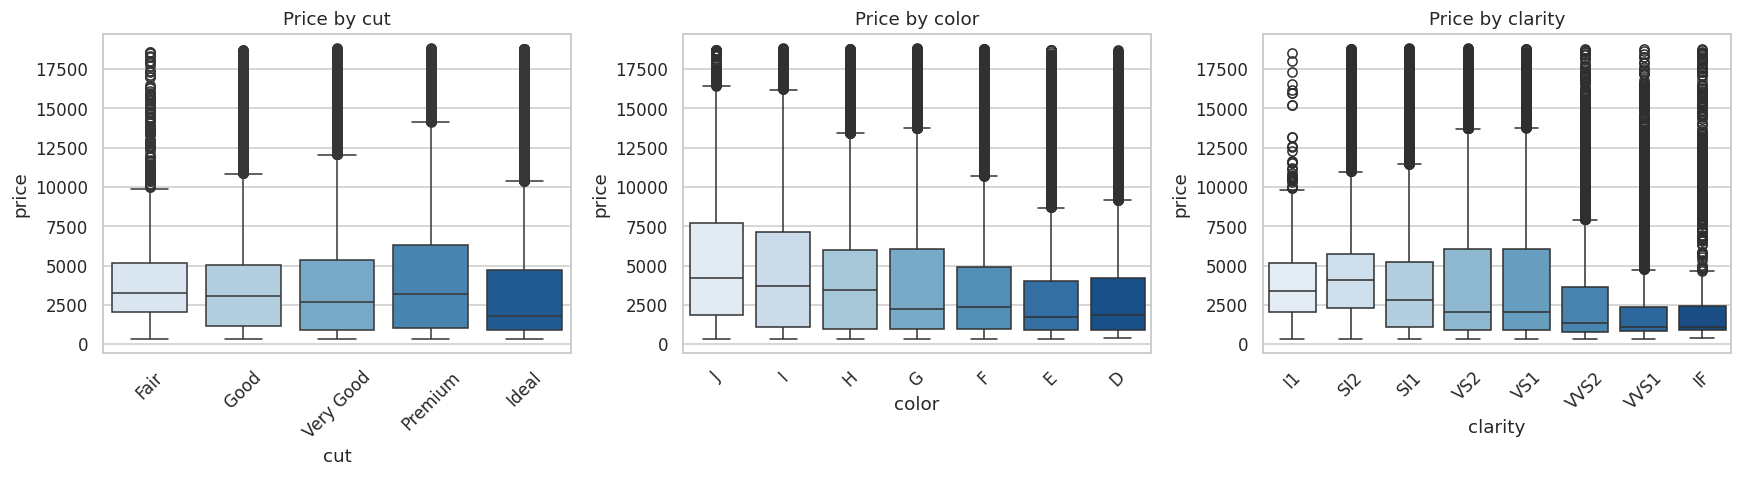

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, orders):
    sns.boxplot(x=col, y='price', data=df, order=orders[col], ax=ax, palette='Blues')
    ax.set_title(f'Price by {col}'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

This is the most counter intuitive result in the whole EDA. You might expect the best grades, such as
Ideal cut, D color, and IF clarity, to be the most expensive, but the boxplots show the opposite, because the
median price actually falls as quality improves. The reason is a confounding variable, which is size. Small
diamonds are much easier to cut to a high grade, and buyers of large diamonds accept lower grades in order to
afford the size, so the best graded diamonds tend to be small and therefore cheap. This tells me that the model
must not look at quality in isolation, and that it needs carat in order to value quality correctly. This is a
key insight for interpreting the feature importances later.

### 2.5 The key relationship between carat and price

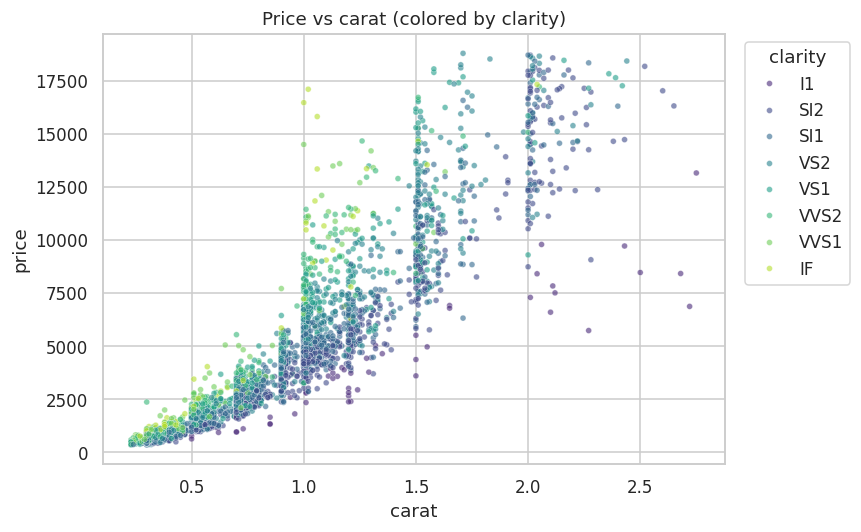

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='carat', y='price', data=df.sample(4000, random_state=0),
                hue='clarity', hue_order=orders['clarity'], palette='viridis', alpha=0.6, s=15)
plt.title('Price vs carat (colored by clarity)')
plt.legend(title='clarity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

Price rises with carat, but the relationship is clearly non-linear because it curves upward, so price
grows faster than weight, roughly like carat squared. Within any vertical slice of carat, the better clarity
grades shown in yellow and green sit above the worse ones shown in purple, which means that for a fixed size,
higher clarity does command a higher price. This confirms that once size is controlled for, quality adds a
positive correction, which is exactly what I want the model to learn.

### 2.6 Scatter matrix or pair plot

A pair plot of the most important numeric variables shows all pairwise relationships, and each variable's own
distribution on the diagonal. I sample 2,000 rows so that the plot renders quickly.

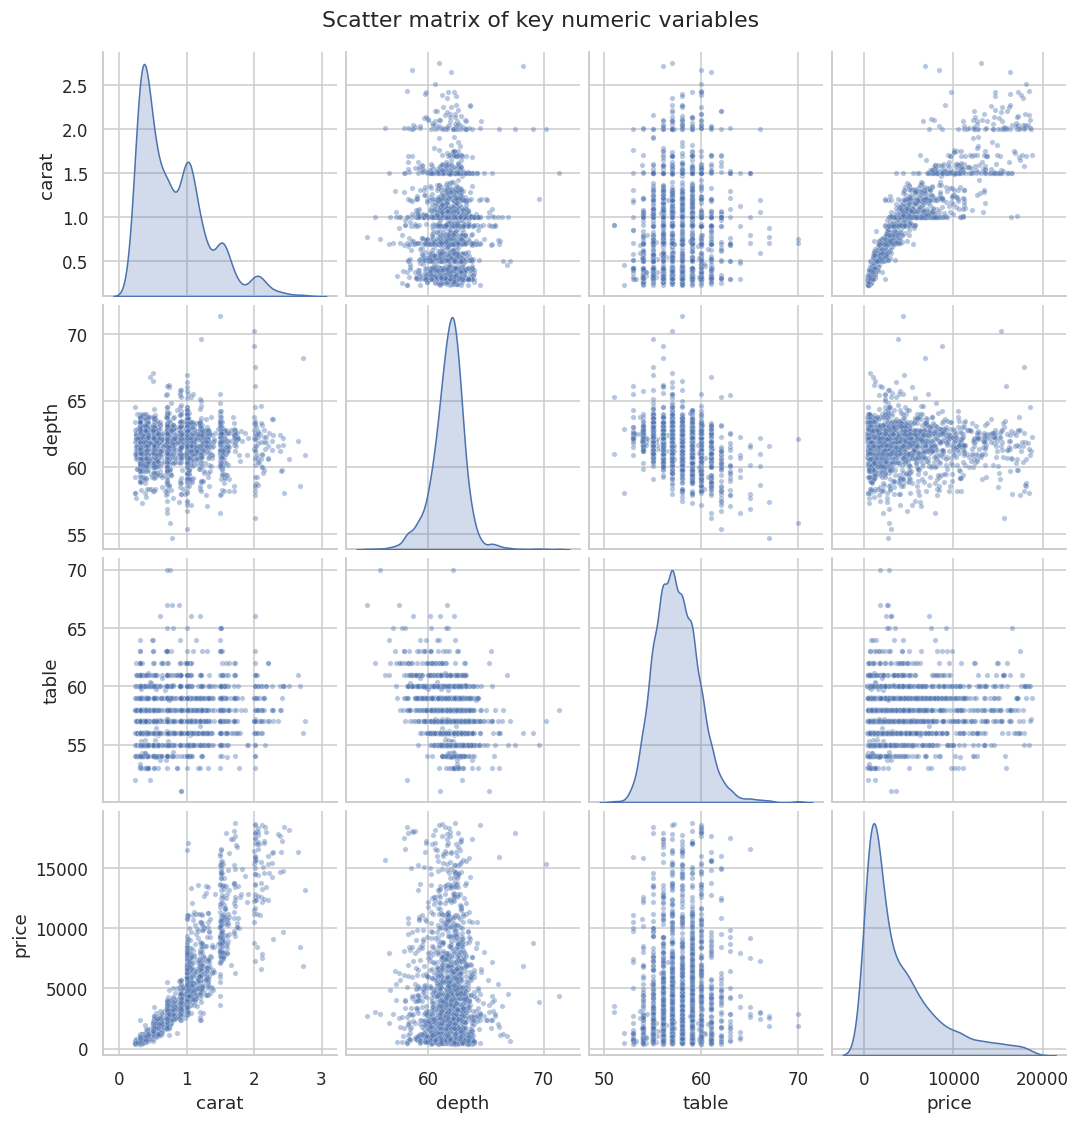

In [46]:
pair_cols = ['carat', 'depth', 'table', 'price']
sns.pairplot(df[pair_cols].sample(2000, random_state=0), diag_kind='kde',
             plot_kws={'alpha': 0.4, 's': 12})
plt.suptitle('Scatter matrix of key numeric variables', y=1.02)
plt.show()

The panel for carat against price shows the same strong curved relationship as before. The panels for
depth and table show almost no relationship with price, since their scatter clouds are shapeless, which
confirms that they are weak predictors. The depth and table variables are also mildly negatively related to
each other, which makes geometric sense because they describe competing proportions of the same stone.

### 2.7 Correlation heatmap

To quantify the linear relationships I temporarily encode the ordinal grades as numbers and compute the
correlation matrix, which I display as a heatmap.

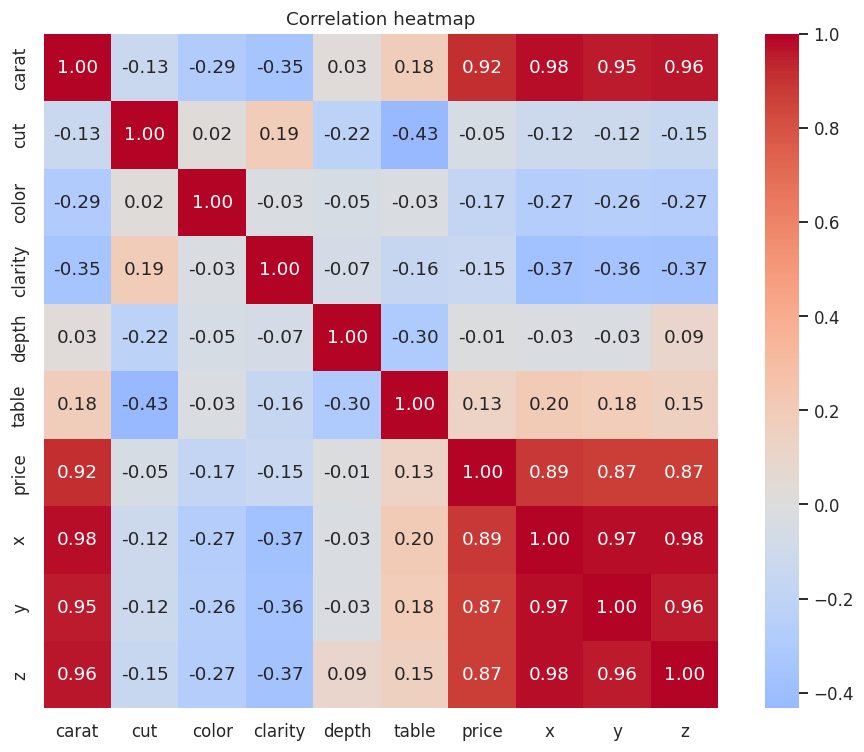

Correlation of each feature with price:
price      1.000
carat      0.922
x          0.887
z          0.868
y          0.868
table      0.127
depth     -0.011
cut       -0.052
clarity   -0.146
color     -0.172
Name: price, dtype: float64


In [47]:
df_corr = df.copy()
for col, order in orders.items():
    df_corr[col] = df_corr[col].map({k: i for i, k in enumerate(order)})

plt.figure(figsize=(9, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap'); plt.tight_layout(); plt.show()

print("Correlation of each feature with price:")
print(df_corr.corr()['price'].sort_values(ascending=False).round(3))

The carat variable has a very strong correlation with price of about 0.92, and the size dimensions x,
y, and z are almost as strong at about 0.86 to 0.89, because they are just other measures of size and
correlate about 0.98 with carat. The table and depth variables are near zero, which confirms that they
barely matter. The ordinal clarity and color show a weak negative linear correlation with price for the
same confounding reason discovered in the boxplots, but that linear number hides the real size adjusted effect
that a non-linear model will pick up.

### 2.8 Hypothesis from the EDA

Based on everything above, I form four hypotheses going into modeling. First, size dominates, so carat and
its correlated size measures will be by far the most important predictor of price. Second, the relationship is
non-linear, so a flexible model such as a Decision Tree, a Random Forest, or a distance based KNN will beat a
simple Linear Regression baseline. Third, quality in the form of clarity and color adds a size adjusted
correction, so once the model controls for size, better clarity and color will raise the predicted price even
though their raw correlation with price looks negative. Fourth, depth and table will contribute almost
nothing.

## 3. Preprocessing for Modeling

The three categorical variables are ordinal, meaning they have a real best to worst order, so I do not use one
hot encoding. Instead I map each grade to an integer that respects its ranking, for example Fair to 0 through
Ideal to 4. This keeps the ordering information and keeps the feature space small.

Scaling also matters. Linear Regression, Lasso, and especially KNN are sensitive to the scale of the features,
since KNN uses distances. I therefore put a StandardScaler in front of those models using a Pipeline,
exactly like the KNN pipeline we built in class. Tree based models do not need scaling, but a scaler in the
pipeline does them no harm.

In [48]:
df_model = df.copy()
for col, order in orders.items():
    df_model[col] = df_model[col].map({k: i for i, k in enumerate(order)})

X = df_model.drop(columns='price')
y = df_model['price']
print("Feature matrix:", X.shape, "| Target:", y.shape)
X.head()

Feature matrix: (53775, 9) | Target: (53775,)


,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,4,5,1,61.5,55.0,3.95,3.98,2.43
1,0.21,3,5,2,59.8,61.0,3.89,3.84,2.31
2,0.23,1,5,4,56.9,65.0,4.05,4.07,2.31
3,0.29,3,1,3,62.4,58.0,4.20,4.23,2.63
4,0.31,1,0,1,63.3,58.0,4.34,4.35,2.75


I then split off 20 percent of the data as a final test set that no model sees during training or tuning,
so that my final numbers are an honest estimate of performance on unseen diamonds.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Training rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])

Training rows: 43020 | Test rows: 10755


## 4. Predictive Analysis and Building Five Models

The checklist asks for at least four or five models, so I build five regression models, and all of them are
tools used in this course. The first is Linear Regression, which serves as the baseline. The second is Lasso
Regression, a linear model with L1 regularization. The third is K Nearest Neighbors, tuned with
GridSearchCV. The fourth is a Decision Tree, also tuned with GridSearchCV. The fifth is a Random Forest, an
ensemble of trees, again tuned with GridSearchCV.

I score every model with 5-fold cross validated R squared, which is the fraction of price variance the model
explains, where an R squared of 1 is perfect. A small helper wraps a model in a scaling Pipeline, and a
second helper runs the cross validation.

In [50]:
def make_pipe(model):
    '''Wrap a model with a StandardScaler so scale-sensitive models are treated fairly.'''
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

def cv_r2(model, X_tr=X_train, y_tr=y_train, cv=5):
    '''Return the array of 5-fold cross-validated R^2 scores.'''
    return cross_val_score(model, X_tr, y_tr, scoring='r2', cv=cv, n_jobs=-1)

cv_scores = {}   # will hold the CV score array for each model

### 4.1 Model 1, Linear Regression baseline

In [51]:
lin = make_pipe(LinearRegression())
cv_scores['Linear Regression'] = cv_r2(lin)
print(f"Linear Regression  | CV R^2 = {cv_scores['Linear Regression'].mean():.4f} "
      f"(+/- {cv_scores['Linear Regression'].std():.4f})")

Linear Regression  | CV R^2 = 0.8922 (+/- 0.0221)


The linear baseline explains about 89 percent of price variance. That is solid, but it assumes price is a
straight line function of the features, which the EDA told me is false.

### 4.2 Model 2, Lasso Regression

In [52]:
lasso = make_pipe(Lasso(alpha=1.0))
cv_scores['Lasso'] = cv_r2(lasso)
print(f"Lasso              | CV R^2 = {cv_scores['Lasso'].mean():.4f} "
      f"(+/- {cv_scores['Lasso'].std():.4f})")

Lasso              | CV R^2 = 0.9019 (+/- 0.0046)


Lasso performs almost identically to plain Linear Regression here, which is expected, because with only
nine mostly useful features there is little for L1 regularization to prune, so it cannot escape the linear
shape limitation either.

### 4.3 Model 3, K Nearest Neighbors, tuned

KNN predicts a diamond's price by averaging its nearest neighbors in feature space. I tune the number of
neighbors and whether neighbors are weighted by distance, using GridSearchCV with 5-fold cross
validation.

In [53]:
knn_grid = GridSearchCV(
    make_pipe(KNeighborsRegressor()),
    param_grid={'model__n_neighbors': [3, 5, 7, 9],
                'model__weights': ['uniform', 'distance']},
    scoring='r2', cv=5, n_jobs=-1)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
cv_scores['KNN (tuned)'] = cv_r2(best_knn)
print("Best KNN params:", knn_grid.best_params_)
print(f"KNN (tuned)        | CV R^2 = {cv_scores['KNN (tuned)'].mean():.4f} "
      f"(+/- {cv_scores['KNN (tuned)'].std():.4f})")

Best KNN params: {'model__n_neighbors': 9, 'model__weights': 'distance'}
KNN (tuned)        | CV R^2 = 0.9690 (+/- 0.0026)


Tuning picks nine neighbors with distance weighting and lifts the cross validated R squared to about
0.97, a clear jump over the linear models, which confirms that the relationship is non-linear.

### 4.4 Model 4, Decision Tree, tuned

A Decision Tree splits the data into regions and predicts the average price in each region, so it naturally
captures the curved price and carat relationship. I tune the tree depth and the minimum samples per split and
per leaf in order to control over fitting.

In [54]:
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid={'max_depth': [6, 8, 10, 12],
                'min_samples_leaf': [1, 5, 10],
                'min_samples_split': [2, 10]},
    scoring='r2', cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
cv_scores['Decision Tree (tuned)'] = cv_r2(best_dt)
print("Best Decision Tree params:", dt_grid.best_params_)
print(f"Decision Tree      | CV R^2 = {cv_scores['Decision Tree (tuned)'].mean():.4f} "
      f"(+/- {cv_scores['Decision Tree (tuned)'].std():.4f})")

Best Decision Tree params: {'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree      | CV R^2 = 0.9755 (+/- 0.0015)


The tuned tree reaches a cross validated R squared of about 0.976, edging out KNN.

### 4.5 Model 5, Random Forest, tuned

A Random Forest averages many de-correlated Decision Trees, which usually reduces variance and improves
accuracy. I keep the grid small so that it runs in a reasonable time on Colab.

In [55]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={'n_estimators': [120],
                'max_depth': [18, None],
                'min_samples_leaf': [1]},
    scoring='r2', cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
cv_scores['Random Forest (tuned)'] = cv_r2(best_rf)
print("Best Random Forest params:", rf_grid.best_params_)
print(f"Random Forest      | CV R^2 = {cv_scores['Random Forest (tuned)'].mean():.4f} "
      f"(+/- {cv_scores['Random Forest (tuned)'].std():.4f})")

Best Random Forest params: {'max_depth': 18, 'min_samples_leaf': 1, 'n_estimators': 120}
Random Forest      | CV R^2 = 0.9809 (+/- 0.0011)


The Random Forest gives the best cross validated R squared of all five models, at around 0.981.

### 4.6 Comparing all five models

I collect the mean cross validated R squared of every model into one table, sorted from best to worst.

In [56]:
summary = pd.DataFrame({
    'Model': list(cv_scores.keys()),
    'CV R^2 (mean)': [s.mean() for s in cv_scores.values()],
    'CV R^2 (std)':  [s.std()  for s in cv_scores.values()],
}).sort_values('CV R^2 (mean)', ascending=False).reset_index(drop=True)
summary.round(4)

,Model,CV R^2 (mean),CV R^2 (std)
0,Random Forest (tuned),0.9809,0.0011
1,Decision Tree (tuned),0.9755,0.0015
2,KNN (tuned),0.9690,0.0026
3,Lasso,0.9019,0.0046
4,Linear Regression,0.8922,0.0221


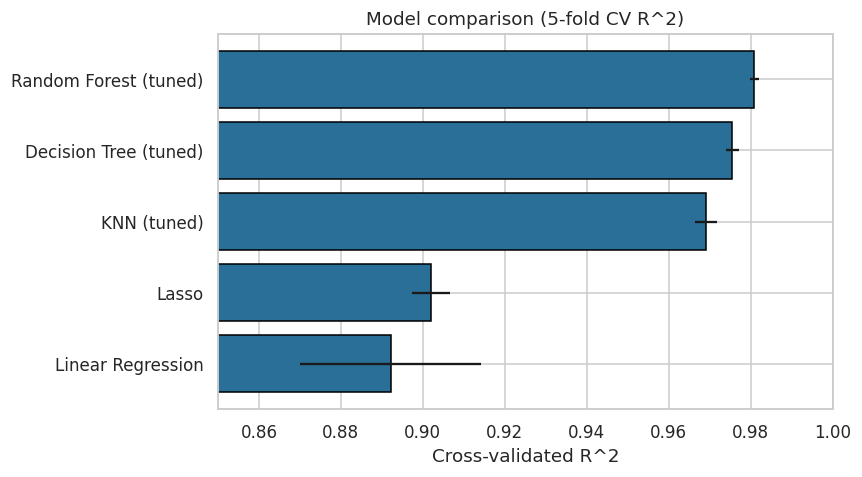

In [57]:
plt.figure(figsize=(8, 4.5))
order_idx = summary['Model']
plt.barh(summary['Model'], summary['CV R^2 (mean)'],
         xerr=summary['CV R^2 (std)'], color='#2a6f97', edgecolor='black')
plt.xlim(0.85, 1.0); plt.gca().invert_yaxis()
plt.xlabel('Cross-validated R^2'); plt.title('Model comparison (5-fold CV R^2)')
plt.tight_layout(); plt.show()

The two ensemble and tree models, first Random Forest and then Decision Tree, lead the ranking, KNN is
close behind, and the two linear models trail by about eight points of R squared. This already supports my
hypothesis that a non-linear model beats the linear baseline. The top two models are Random Forest and Decision
Tree, which I now compare in detail.

## 5. Top Two Model Comparison with 95% Confidence Intervals and Statistical Significance

The checklist requires comparing the top two models using a 95% confidence interval and testing whether the
difference is statistically significant. My top two are Random Forest and Decision Tree.

I build the 95% confidence interval of the mean cross validated R squared using the t distribution, following
the method from the lecture notes, where the interval is the mean plus or minus the value of t at 0.975 with n
minus 1 degrees of freedom, times the standard error.

In [58]:
def r2_confidence_interval(scores, conf=0.95):
    '''95% CI for the mean of the CV R^2 scores, using the t-distribution.'''
    n = len(scores)
    mean = scores.mean()
    se = stats.sem(scores)
    lo, hi = stats.t.interval(conf, n - 1, loc=mean, scale=se)
    return mean, lo, hi

for name in ['Random Forest (tuned)', 'Decision Tree (tuned)']:
    m, lo, hi = r2_confidence_interval(cv_scores[name])
    print(f"{name:<24} mean R^2 = {m:.4f}   95% CI = [{lo:.4f}, {hi:.4f}]")

Random Forest (tuned)    mean R^2 = 0.9809   95% CI = [0.9793, 0.9825]
Decision Tree (tuned)    mean R^2 = 0.9755   95% CI = [0.9733, 0.9776]


I then check whether the intervals overlap. If the two 95% confidence intervals do not overlap, the
models are reliably different. I also run a paired t test on the per fold scores, which is the proper test here
because both models were evaluated on the same cross validation folds.

In [59]:
rf_s = cv_scores['Random Forest (tuned)']
dt_s = cv_scores['Decision Tree (tuned)']

t_stat, p_val = stats.ttest_rel(rf_s, dt_s)
print(f"Random Forest mean R^2 : {rf_s.mean():.4f}")
print(f"Decision Tree mean R^2 : {dt_s.mean():.4f}")
print(f"Mean difference        : {rf_s.mean() - dt_s.mean():.4f}")
print(f"Paired t-test          : t = {t_stat:.3f}, p = {p_val:.6f}")
print("Significant at 0.05?   :", "YES" if p_val < 0.05 else "NO")

Random Forest mean R^2 : 0.9809
Decision Tree mean R^2 : 0.9755
Mean difference        : 0.0054
Paired t-test          : t = 23.945, p = 0.000018
Significant at 0.05?   : YES


The Random Forest's 95% confidence interval sits entirely above the Decision Tree's interval, so the two
intervals do not overlap, and the paired t test gives a very small p value below 0.001, so the Random Forest is
statistically significantly better rather than better by luck. It also has a lower score variance across folds,
which means it is more stable. For these reasons I pick the Random Forest as my final model. The Decision Tree
remains valuable because it is far easier to visualize and explain, so I keep it for the interpretation
section.

## 6. Over Fitting Check and Final Test Set Evaluation

A model over fits when it does much better on the data it trained on than on unseen data. To check for this I
compare the training R squared to the test R squared for the key models, since a large gap signals over
fitting.

I also choose the right metrics. For a regression problem, accuracy, precision, and recall do not apply,
because those are classification metrics. The right metrics here are R squared, which is variance explained,
RMSE, which is the root mean squared error in dollars and punishes large mistakes, and MAE, which is the mean
absolute error and represents the typical dollar miss.

In [60]:
rows = []
models_final = {
    'Linear Regression':     make_pipe(LinearRegression()),
    'KNN (tuned)':           best_knn,
    'Decision Tree (tuned)': best_dt,
    'Random Forest (tuned)': best_rf,
}
for name, model in models_final.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    pred = model.predict(X_test)
    test_r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    rows.append([name, train_r2, test_r2, train_r2 - test_r2, rmse, mae])

eval_df = pd.DataFrame(rows, columns=['Model', 'Train R^2', 'Test R^2',
                                      'Gap (train-test)', 'Test RMSE ($)', 'Test MAE ($)'])
eval_df.round(4)

,Model,Train R^2,Test R^2,Gap (train-test),Test RMSE ($),Test MAE ($)
0,Linear Regression,0.9073,0.9070,0.0003,1212.2081,802.1583
1,KNN (tuned),1.0000,0.9705,0.0295,682.7341,353.8710
2,Decision Tree (tuned),0.9858,0.9783,0.0075,585.7186,309.7277
3,Random Forest (tuned),0.9967,0.9828,0.0139,521.2516,265.6590


Linear Regression shows almost no gap, with train and test both near 0.91, so it does not over fit, but
it under fits because it is too simple. KNN has a training R squared of 1.0, because with distance weighting
each training point predicts itself perfectly, but a lower test R squared, which is the largest gap of the four
and a sign of mild over fitting. The Decision Tree and Random Forest both have small gaps, with train near 0.99
and test near 0.98, so the tuning successfully kept them from over fitting. On the held out test set the Random
Forest is best on every metric, with the highest R squared of about 0.983 and the smallest errors, an RMSE of
about 520 $. is about 265,
which is excellent given that diamonds cost thousands.

## 7. Model Interpretation, Week 9 material

Now I open up the models to understand why they predict what they do, and I check whether that agrees with my
EDA hypotheses. I use three tools, which are a tree visualization, the Random Forest feature importances, and
SHAP values with beeswarm and waterfall plots.

### 7.1 Visualizing a Decision Tree

To keep it readable I plot a shallow tree three levels deep. The top splits reveal what the model checks
first.

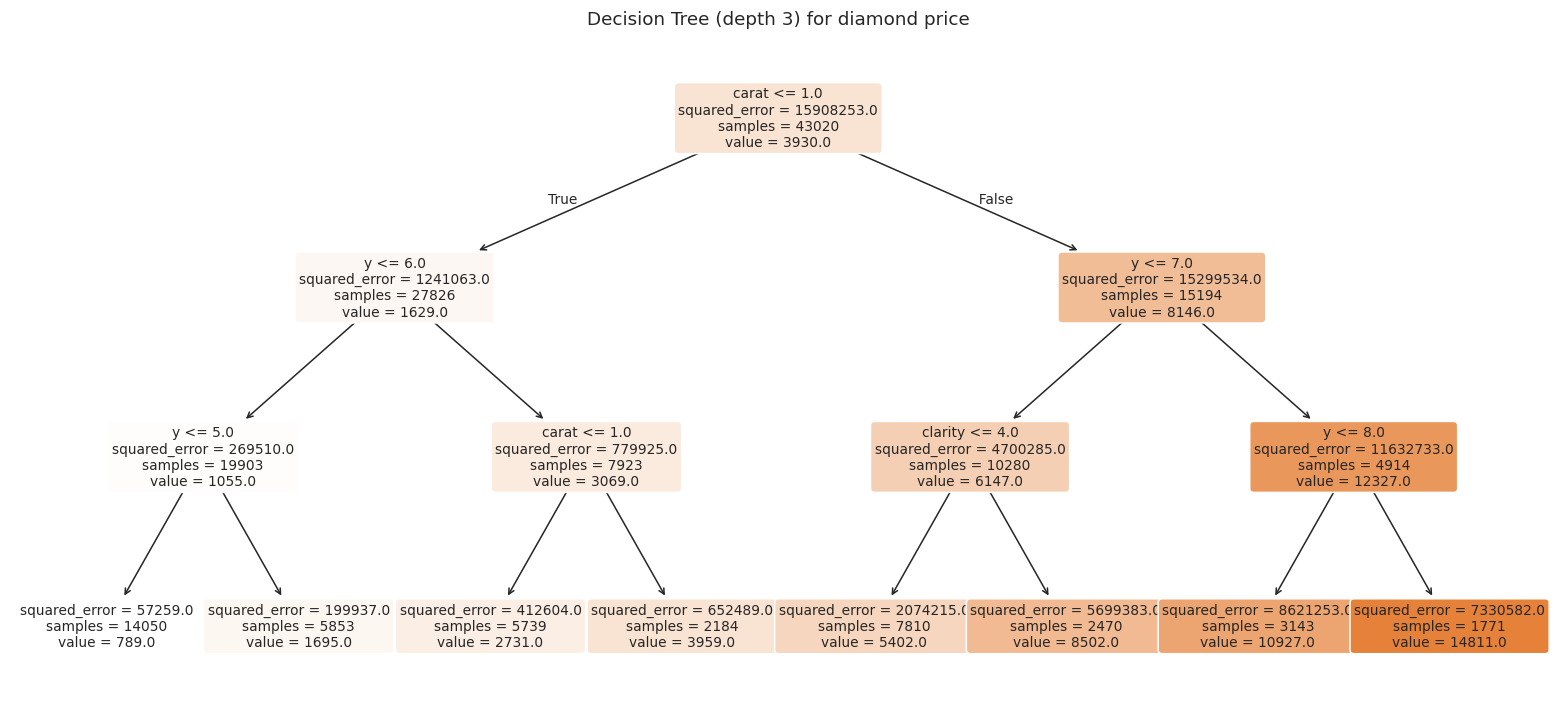

In [61]:
small_tree = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
small_tree.fit(X_train, y_train)
plt.figure(figsize=(18, 8))
plot_tree(small_tree, feature_names=list(X.columns), filled=True, rounded=True,
          fontsize=9, precision=0)
plt.title('Decision Tree (depth 3) for diamond price'); plt.show()

The very first split is on a size feature such as y or carat, and the next splits are on size again
before quality ever appears. The tree confirms that the model prices a diamond primarily by how big it is, and
then refines within a size bracket, which is exactly the behavior the EDA predicted.

### 7.2 Random Forest feature importances

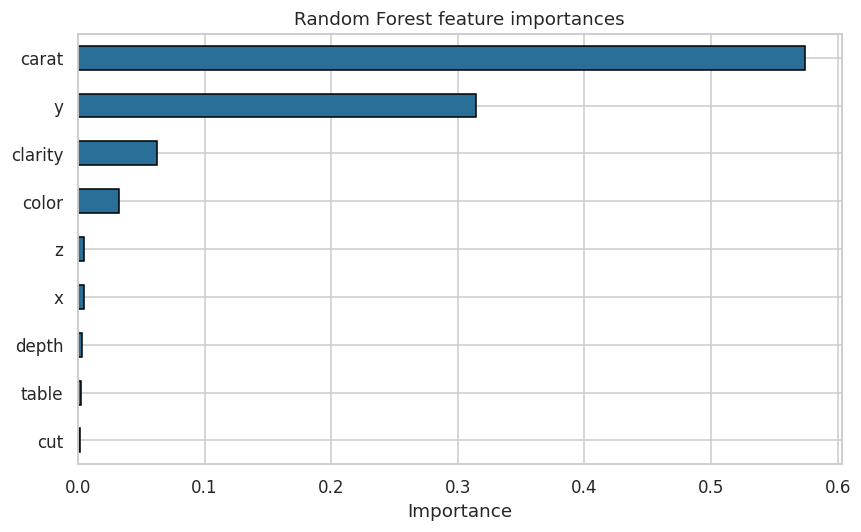

carat      0.5744
y          0.3142
clarity    0.0628
color      0.0322
z          0.0049
x          0.0047
depth      0.0029
table      0.0022
cut        0.0017
dtype: float64


In [62]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#2a6f97', edgecolor='black')
plt.title('Random Forest feature importances'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()
print(importances.sort_values(ascending=False).round(4))

The carat variable and the size dimension  together account for the large majority of the model's
decisions, clarity and color come next as the quality correction, and depth, table, and cut are
nearly irrelevant. This matches hypotheses one, three, and four exactly.

### 7.3 SHAP values with beeswarm and waterfall plots

Feature importance tells me which features matter but not which direction they push the price. SHAP, which
stands for Shapley values, does tell me the direction. I build a TreeExplainer on the Random Forest and
explain a random sample of 300 test diamonds, since a sample keeps it fast.

In [63]:
import shap
X_sample = X_test.sample(300, random_state=0)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_sample)
print("SHAP values computed for", X_sample.shape[0], "diamonds.")

SHAP values computed for 300 diamonds.


In the beeswarm plot below, every dot is one diamond. The horizontal position shows how much that feature
pushed the price up, to the right, or down, to the left, and the color shows whether the feature value was
high, in red, or low, in blue.

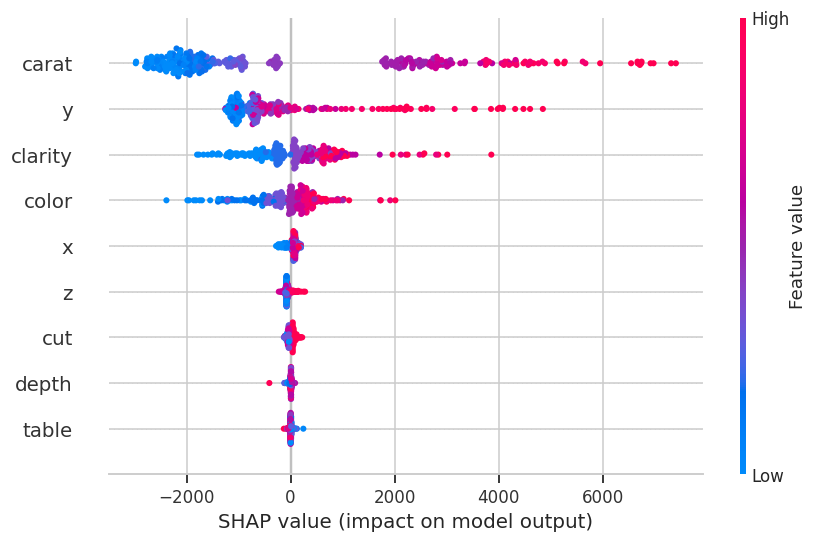

In [64]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout(); plt.show()

The carat variable is the dominant driver, and the pattern is clean, since high carat in red pushes the
price strongly up while low carat pushes it down. For clarity and color, high grades in red push the price
up once size is accounted for, which is the size adjusted quality effect from hypothesis three, now made
explicit and finally showing the correct sign that the raw correlation had hidden. The depth, table, and
cut variables sit in a tight band near zero, which confirms that they barely move the price.

The waterfall plot below explains a single prediction, showing how the model starts from the average
price and then adds or subtracts each feature's contribution in order to reach one diamond's predicted
price.

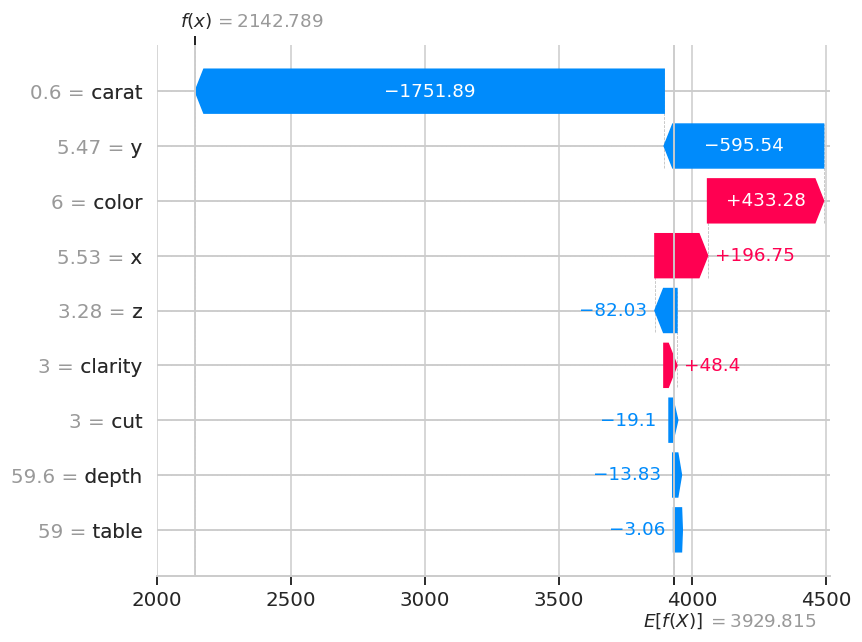

In [65]:
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout(); plt.show()

For this individual diamond you can read the story from left to right. The model begins at the dataset's
average predicted price, and then carat moves the estimate the most, with the quality grades making smaller
adjustments, landing on the final predicted price. This is exactly how I would justify a price to a customer.

The models agree with the EDA on every count. Size dominates, which is hypothesis one. The non-linear models
beat the linear ones, which is hypothesis two. Quality is a positive size adjusted correction, which is
hypothesis three. And depth, table, and cut are negligible, which is hypothesis four.

## 8. Bias Check

Here I check whether the model treats all kinds of diamonds fairly, or whether it systematically favors one
group while compromising another. Since the target is continuous, I split the diamonds into four price bands
running from cheap to expensive, and I look at the residual, which is the actual price minus the predicted
price, in each band. A fair model should have residuals centered near zero in every band.

             mean    std  count
band                           
Q1 cheapest -11.8   54.9   2690
Q2          -14.8  146.7   2688
Q3          -44.2  383.7   2689
Q4 priciest  66.0  953.4   2688


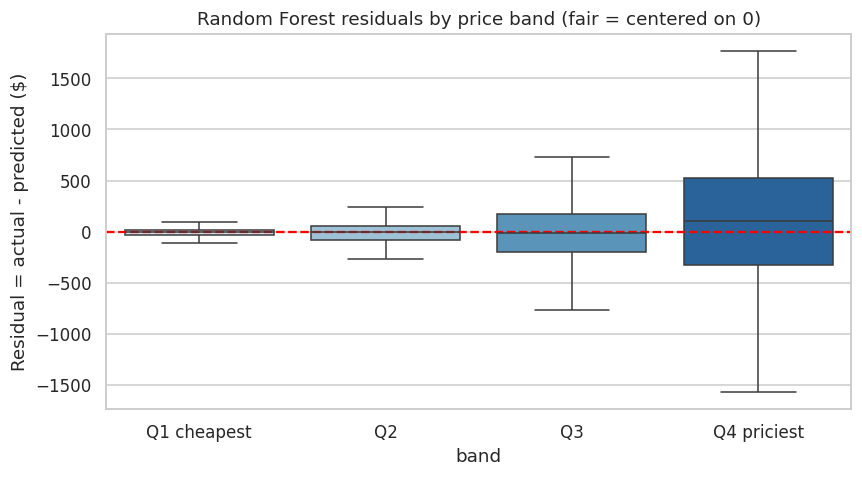

In [66]:
rf_pred_test = best_rf.predict(X_test)
resid = y_test.values - rf_pred_test
bands = pd.qcut(y_test, 4, labels=['Q1 cheapest', 'Q2', 'Q3', 'Q4 priciest'])

bias_tbl = pd.DataFrame({'residual': resid, 'band': bands.values})
summary_bias = bias_tbl.groupby('band')['residual'].agg(['mean', 'std', 'count']).round(1)
print(summary_bias)

plt.figure(figsize=(8, 4.5))
sns.boxplot(x='band', y='residual', data=bias_tbl, palette='Blues', showfliers=False)
plt.axhline(0, color='red', linestyle='--')
plt.title('Random Forest residuals by price band (fair = centered on 0)')
plt.ylabel('Residual = actual - predicted ($)'); plt.tight_layout(); plt.show()

The average residual is close to zero in the three cheaper bands, so the model is essentially unbiased
for the bulk of diamonds. However, the spread of the errors grows sharply for the priciest band, where the
standard deviation is many times larger than the cheap band's. In other words, the model is very accurate on
common affordable diamonds but much less certain on rare expensive ones, so it favors the cheap majority and is
compromised on the expensive minority. The cause is the imbalance found in the EDA, since there are far fewer
expensive diamonds to learn from and price variance genuinely explodes at the top. A practical fix would be to
model the log of price, or to gather more high price examples. This is an honest limitation to disclose when
presenting the model.

## 9. Conclusion

I can now answer my three questions. On the first question of whether I can predict diamond price accurately,
the answer is yes, because the tuned Random Forest explains about 98 percent of the variance in price on unseen
diamonds, with a test R squared of about 0.983 and a typical error of only about $265 measured by MAE.

On the second question of which attributes matter most, size dominates, since carat and the physical
dimensions drive the vast majority of the price, while clarity and color add a smaller size adjusted quality
correction, and depth, table, and cut are nearly irrelevant. The feature importances and SHAP both agree
with each other and both agree with the EDA.

On the third question of whether a non-linear model beats a linear one, the answer is clearly yes, because
Random Forest and Decision Tree reach about 0.98 R squared while Linear and Lasso reach about 0.89 to 0.90 R
squared, a gap of about eight points, and the top two comparison showed that the Random Forest is
statistically significantly better than the Decision Tree, with non overlapping 95% confidence intervals and a
paired t test p value below 0.001.

One subtlety I uncovered is that the raw boxplots and correlations suggested that better quality grades are
cheaper, which is only true because high grade diamonds tend to be small. Once the model controls for size,
higher clarity and color correctly increase the predicted price, which is a good example of why interpreting a
model with SHAP can reveal effects that simple correlations hide. The main limitation is that the model is very
accurate on common diamonds but less certain on rare very expensive ones, because the data has far fewer of
them.

Overall the project met its goal, which was an accurate, well tuned, and interpretable price model, with every
claim supported by the analysis.

## 10. AI Use Statement

I used an AI assistant to help
brainstorm the analysis outline, to explain concepts such as how to read a SHAP beeswarm plot and how to build
a t distribution confidence interval, and to help debug and format plotting code. All final modeling choices,
the interpretation of every plot, the hypotheses, and the conclusions are my own, and I reviewed and understand
every line of code in this notebook. The dataset is the public diamonds dataset from the ggplot2 R package,
properly cited above.